In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import OneHotEncoder
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Importar el dataset

In [2]:
data = pd.read_csv('./Data.csv')

C:\Users\Dell\AppData\Local\Temp\ipykernel_24608\2202040361.py:1: DtypeWarning: Columns (30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./Data.csv')


### Informacion de la data

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17087 entries, 0 to 17086
Data columns (total 77 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   md5                         17087 non-null  object 
 1   sha1                        17087 non-null  object 
 2   file_extension              17087 non-null  object 
 3   EntryPoint                  17087 non-null  object 
 4   PEType                      17087 non-null  object 
 5   MachineType                 17087 non-null  object 
 6   magic_number                17087 non-null  object 
 7   bytes_on_last_page          17087 non-null  object 
 8   pages_in_file               17087 non-null  object 
 9   relocations                 17087 non-null  object 
 10  size_of_header              17087 non-null  object 
 11  min_extra_paragraphs        17087 non-null  object 
 12  max_extra_paragraphs        17087 non-null  object 
 13  init_ss_value               170

### Numero de columnas y filas

In [4]:
print("Shape", data.shape)
print("Filas", data.shape[0])
print("Columnas", data.shape[1])

Shape (17087, 77)
Filas 17087
Columnas 77


### Listar todas las columnas por tipo de varibale: categorica y numerica

In [5]:
# --- Detectar columnas categóricas ---
cat_cols = data.select_dtypes(include=["object"]).columns.tolist()

print("Columnas categóricas:")
print(cat_cols)

Columnas categóricas:
['md5', 'sha1', 'file_extension', 'EntryPoint', 'PEType', 'MachineType', 'magic_number', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'oem_identifier', 'address_of_ne_header', 'Magic', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'OperatingSystemVersion', 'ImageVersion', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_PointerToRelocations', 'text_PointerToLineNumbers', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rda

In [929]:
# --- Detectar columnas numericas ---
num_cols = data.select_dtypes(include=["float64"]).columns.tolist()

print("Columnas numericas detectadas:")
print(num_cols )

Columnas numericas detectadas:
['registry_read', 'registry_write', 'registry_delete', 'registry_total', 'network_threats', 'network_dns', 'network_http', 'network_connections', 'processes_malicious', 'processes_suspicious', 'processes_monitored', 'total_procsses', 'files_malicious', 'files_suspicious', 'files_text', 'files_unknown', 'dlls_calls', 'apis']


### Cantidad de  variables numericas y categoricas

In [930]:
data.dtypes.value_counts()


object     59
float64    18
Name: count, dtype: int64

### Revisar la cardinalidad de las variables categoricas
Para ver si se aplica one-hot Encoder o Label Enconder
One-hot Se aplica a variables que tenga pocas categorias
Label Encoder 
Ventajas no crea varias columnas Útil para modelos que no interpretan los números como un orden (ej. árboles: Decision Tree, Random Forest, XGBoost, LightGBM). 
Todas esas variables estan categorizadas como object, en las cuales algunas eran object y otras eran hexcd que estans como object


In [931]:
# --- Revisar cardinalidad (número de valores únicos) ---
cat_cardinalidad = {c: data[c].nunique() for c in cat_cols}
print("\nCardinalidad de columnas categóricas:")
for col, nunique in cat_cardinalidad.items():
    print(f"{col}: {nunique}")


Cardinalidad de columnas categóricas:
md5: 9855
sha1: 9856
file_extension: 1
EntryPoint: 6191
PEType: 3
MachineType: 3
magic_number: 2
bytes_on_last_page: 64
pages_in_file: 63
relocations: 43
size_of_header: 43
min_extra_paragraphs: 42
max_extra_paragraphs: 40
init_ss_value: 40
init_sp_value: 46
init_ip_value: 52
init_cs_value: 52
over_lay_number: 49
oem_identifier: 47
address_of_ne_header: 69
Magic: 3
SizeOfCode: 2488
SizeOfInitializedData: 2204
SizeOfUninitializedData: 404
AddressOfEntryPoint: 5908
BaseOfCode: 336
BaseOfData: 942
ImageBase: 99
SectionAlignment: 9
FileAlignment: 8
OperatingSystemVersion: 27
ImageVersion: 116
SizeOfImage: 1997
SizeOfHeaders: 24
Checksum: 3621
Subsystem: 5
DllCharacteristics: 57
SizeofStackReserve: 57
SizeofStackCommit: 42
SizeofHeapCommit: 10
SizeofHeapReserve: 22
LoaderFlags: 4
text_VirtualSize: 5553
text_VirtualAddress: 121
text_SizeOfRawData: 2143
text_PointerToRawData: 124
text_PointerToRelocations: 6
text_PointerToLineNumbers: 12
text_Characteris

### Ver los valores nulos

In [932]:
print("\n Conteo de valores nulos por columna:")
print(data.isnull().sum())


 Conteo de valores nulos por columna:
md5                           0
sha1                          0
file_extension                0
EntryPoint                    0
PEType                        0
MachineType                   0
magic_number                  0
bytes_on_last_page            0
pages_in_file                 0
relocations                   0
size_of_header                0
min_extra_paragraphs          0
max_extra_paragraphs          0
init_ss_value                 0
init_sp_value                 0
init_ip_value                 0
init_cs_value                 0
over_lay_number               0
oem_identifier                0
address_of_ne_header          0
Magic                         0
SizeOfCode                    0
SizeOfInitializedData         0
SizeOfUninitializedData       0
AddressOfEntryPoint           0
BaseOfCode                    0
BaseOfData                    0
ImageBase                     0
SectionAlignment              0
FileAlignment                 0
O

### Valores vacios por columna

In [933]:
# 4) Detectar valores vacíos (celdas con string vacío o solo espacios)
print("\n Conteo de valores vacíos por columna:")
print((data.applymap(lambda x: str(x).strip() == '')).sum())




 Conteo de valores vacíos por columna:


C:\Users\Dell\AppData\Local\Temp\ipykernel_30100\2919232096.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print((data.applymap(lambda x: str(x).strip() == '')).sum())


md5                           0
sha1                          0
file_extension                0
EntryPoint                    0
PEType                        0
MachineType                   0
magic_number                  0
bytes_on_last_page            0
pages_in_file                 0
relocations                   0
size_of_header                0
min_extra_paragraphs          0
max_extra_paragraphs          0
init_ss_value                 0
init_sp_value                 0
init_ip_value                 0
init_cs_value                 0
over_lay_number               0
oem_identifier                0
address_of_ne_header          0
Magic                         0
SizeOfCode                    0
SizeOfInitializedData         0
SizeOfUninitializedData       0
AddressOfEntryPoint           0
BaseOfCode                    0
BaseOfData                    0
ImageBase                     0
SectionAlignment              0
FileAlignment                 0
OperatingSystemVersion        0
ImageVer

### Ver  filas vacias

In [934]:
# 5) Detectar filas completamente vacías
print("\n Número de filas completamente vacías:")
print(data.isnull().all(axis=1).sum())


 Número de filas completamente vacías:
0


In [935]:
# 6) Ver filas sospechosas (con valores nulos o vacíos en alguna columna)
print("\n Filas con valores nulos o vacíos:")
print(data[data.isnull().any(axis=1) | data.applymap(lambda x: str(x).strip() == '').any(axis=1)])


 Filas con valores nulos o vacíos:


C:\Users\Dell\AppData\Local\Temp\ipykernel_30100\3230463956.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(data[data.isnull().any(axis=1) | data.applymap(lambda x: str(x).strip() == '').any(axis=1)])


Empty DataFrame
Columns: [md5, sha1, file_extension, EntryPoint, PEType, MachineType, magic_number, bytes_on_last_page, pages_in_file, relocations, size_of_header, min_extra_paragraphs, max_extra_paragraphs, init_ss_value, init_sp_value, init_ip_value, init_cs_value, over_lay_number, oem_identifier, address_of_ne_header, Magic, SizeOfCode, SizeOfInitializedData, SizeOfUninitializedData, AddressOfEntryPoint, BaseOfCode, BaseOfData, ImageBase, SectionAlignment, FileAlignment, OperatingSystemVersion, ImageVersion, SizeOfImage, SizeOfHeaders, Checksum, Subsystem, DllCharacteristics, SizeofStackReserve, SizeofStackCommit, SizeofHeapCommit, SizeofHeapReserve, LoaderFlags, text_VirtualSize, text_VirtualAddress, text_SizeOfRawData, text_PointerToRawData, text_PointerToRelocations, text_PointerToLineNumbers, text_Characteristics, rdata_VirtualSize, rdata_VirtualAddress, rdata_SizeOfRawData, rdata_PointerToRawData, rdata_PointerToRelocations, rdata_PointerToLineNumbers, rdata_Characteristics, re

### Distribucion multiclase Bening, Ransoware y Trojan
Esta desbalanceada la clase

Distribución de clases:
 Category
Benign        10876
Ransomware     4762
Trojan         1449
Name: count, dtype: int64


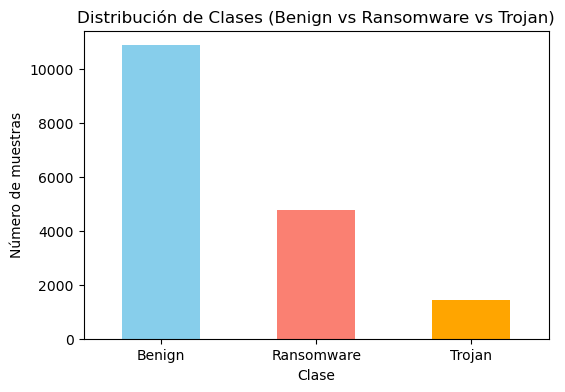

In [936]:
# Contar muestras por categoría
class_counts = data["Category"].value_counts()

# Imprimir valores exactos
print("Distribución de clases:\n", class_counts)

# Graficar
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
class_counts.plot(kind="bar", color=["skyblue", "salmon", "orange"])
plt.title("Distribución de Clases (Benign vs Ransomware vs Trojan)")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(rotation=0)
plt.show()


### Definir features (X)
Ahora X contiene solo las características.

In [6]:
X = data.drop(columns=["Class", "Category", "Family"], errors="ignore")
print("Shape de X (features):", X.shape)

Shape de X (features): (17087, 74)


### Definir target

In [7]:
y = data["Category"] # multiclase: Benign, Ransomware, Trojan
print("Shape de y (target):", y.shape)

Shape de y (target): (17087,)


### Eliminacion de columnas que no aportan valor

In [939]:
# 3. Eliminar columnas que no aportan valor
# md5, sha1 identificador
# file_extension tipo de extension exe 
#  "text_PointerToRelocations", "text_PointerToLineNumbers", solo tiene 0
#   "rdata_PointerToRelocations", "rdata_PointerToLineNumbers", solo tiene 0
#magic number no aporta 
# No aporta magic debido a que solo tiene una categoria
#EntryPoint variable redundante con Addres of entrypoint
cols_drop = [
    "md5", "sha1","file_extension","network_threats", "Magic", "magic_number",
    "oem_identifier", "address_of_ne_header",
     "text_PointerToRelocations", "text_PointerToLineNumbers",
    "rdata_PointerToRelocations", "rdata_PointerToLineNumbers",
    "Class", "Category","Family", "registry_total", "total_procsses", "OperatingSystemVersion", "ImageVersion","files_malicious","files_suspicious"
   "files_text, files_unknown","processes_malicious","processes_suspicious","processes_monitored"]
X = X.drop(columns=cols_drop, errors="ignore")
print("Shape de X después de eliminar columnas no útiles:", X.shape)


Shape de X después de eliminar columnas no útiles: (17087, 54)


In [940]:
print("Shape del dataset limpio:", X.shape)
print("Columnas:", X.columns.tolist())


Shape del dataset limpio: (17087, 54)
Columnas: ['EntryPoint', 'PEType', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'Subsystem', 'DllCharacteristics', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'text_Characteristics', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rdata_PointerToRawData', 'rdata_Characteristics', 'registry_read', 'registry_write', 'registry_delete', 'network_dns', 'network_http', 'network_connections', 'processes_suspicious', 'files_sus

### Renombrar variables 

In [941]:
# Conteo de nulos por columna
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


In [942]:
# Reemplazar '0' por IMAGE_SUBSYSTEM_UNKNOWN
if "Subsystem" in X.columns:
    X["Subsystem"] = X["Subsystem"].replace("0", "IMAGE_SUBSYSTEM_UNKNOWN")

print("Categorías únicas después:", X["Subsystem"].unique())
print("Conteo actualizado:")
print(X["Subsystem"].value_counts())




Categorías únicas después: ['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CUI'
 'IMAGE_SUBSYSTEM_NATIVE' 'IMAGE_SUBSYSTEM_UNKNOWN']
Conteo actualizado:
Subsystem
IMAGE_SUBSYSTEM_WINDOWS_GUI    13169
IMAGE_SUBSYSTEM_WINDOWS_CUI     3487
IMAGE_SUBSYSTEM_UNKNOWN          341
IMAGE_SUBSYSTEM_NATIVE            90
Name: count, dtype: int64


### Verificar las variables con error

In [943]:
# Ver todas las filas que tienen ese valor
X[X["PEType"] == "Unknown (0x2000)"]


,EntryPoint,PEType,bytes_on_last_page,pages_in_file,relocations,size_of_header,min_extra_paragraphs,max_extra_paragraphs,init_ss_value,init_sp_value,...,registry_delete,network_dns,network_http,network_connections,processes_suspicious,files_suspicious,files_text,files_unknown,dlls_calls,apis
999,0x0000,Unknown (0x2000),0x0050,0x0002,0x0000,0x0004,0x000F,0xFFFF,0x0000,0x00B8,...,0.0,0.0,0.0,4.0,0.0,0.0,2.0,0.0,0.0,0.0
9655,0x2800a,Unknown (0x2000),0x0050,0x0002,0x0000,0x0004,0x0000,0xFFFF,0x0000,0x0000,...,1.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,0.0,338.0


### Eliminar filas que tienen errores

In [944]:
# === Eliminar filas con PEType = 'Unknown (0x2000)' ===
if "PEType" in X.columns:
    filas_iniciales = X.shape[0]
    mask = X["PEType"] != "Unknown (0x2000)"
    X = X[mask]
    y = y[mask]   # eliminar también en y
    print(f"Filas eliminadas (PEType): {filas_iniciales - X.shape[0]}")



Filas eliminadas (PEType): 2


### Limpieza de la variable AddressOfEntryPoint

In [945]:
def limpiar_hex_con_texto(val):
    if isinstance(val, str):
        val = val.strip()
        if val == "0":       # caso especial: valor 0
            return 0.0
        match = re.search(r"0x[0-9A-Fa-f]+", val)
        if match:
            try:
                return float(int(match.group(0), 16))
            except:
                return np.nan
        return np.nan
    return val
if "AddressOfEntryPoint" in X.columns:
    X["AddressOfEntryPoint"] = (
        X["AddressOfEntryPoint"]
        .map(limpiar_hex_con_texto)
        .astype("float64")
    )
    print("Columna AddressOfEntryPoint corregida sin convertir los '0' a NaN.")
    print("Nulos restantes:", X["AddressOfEntryPoint"].isnull().sum())


Columna AddressOfEntryPoint corregida sin convertir los '0' a NaN.
Nulos restantes: 0


In [946]:
# Conteo de nulos por columna
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


### Convertir las variables  hexadecimales a float


In [947]:
import re
import numpy as np

# === 1) Define las categóricas que NO deben tocarse ===
CATEGORICAS_EXCLUIR = [
    "MachineType", "Subsystem", "PEType",
    "DllCharacteristics", "text_Characteristics", "rdata_Characteristics"
]
cat_presentes = [c for c in CATEGORICAS_EXCLUIR if c in X.columns]

# === 2) Funciones auxiliares ===
HEX_REGEX = re.compile(r"^\s*0[xX][0-9A-Fa-f]+\s*$")

def es_hex(s: str) -> bool:
    return isinstance(s, str) and bool(HEX_REGEX.match(s.strip()))

def parsear_num(val):
    """Convierte hex ('0x...') o decimal en texto a float64. Si falla -> NaN."""
    if isinstance(val, str):
        s = val.strip()
        if es_hex(s):
            try:
                return float(int(s, 16))
            except:
                return np.nan
        try:
            return float(s)
        except:
            return np.nan
    if val is None or (isinstance(val, float) and np.isnan(val)):
        return np.nan
    try:
        return float(val)
    except:
        return np.nan

# === 3) Detectar columnas 'object' con al menos un valor hexadecimal ===
hex_cols = []
for col in X.select_dtypes(include=["object"]).columns:
    if col in cat_presentes:
        continue  # excluye categóricas
    muestra = X[col].dropna().astype(str)
    if muestra.map(es_hex).any():
      hex_cols.append(col)
print("Columnas detectadas con valores hexadecimales:", hex_cols)

# === 4) Convertir SOLO esas columnas a float64 ===
for col in hex_cols:
    X[col] = X[col].map(parsear_num).astype("float64")

# (Opcional) Verificación
print(X[hex_cols].dtypes if hex_cols else "No se detectaron columnas hexadecimales.")

# === 5) Exportar a CSV ===
output_path = "dataset_valoresfloat3.csv"
X.to_csv(output_path, index=False, encoding="utf-8")
print(f"Archivo exportado a: {output_path}")


Columnas detectadas con valores hexadecimales: ['EntryPoint', 'bytes_on_last_page', 'pages_in_file', 'relocations', 'size_of_header', 'min_extra_paragraphs', 'max_extra_paragraphs', 'init_ss_value', 'init_sp_value', 'init_ip_value', 'init_cs_value', 'over_lay_number', 'SizeOfCode', 'SizeOfInitializedData', 'SizeOfUninitializedData', 'BaseOfCode', 'BaseOfData', 'ImageBase', 'SectionAlignment', 'FileAlignment', 'SizeOfImage', 'SizeOfHeaders', 'Checksum', 'SizeofStackReserve', 'SizeofStackCommit', 'SizeofHeapCommit', 'SizeofHeapReserve', 'LoaderFlags', 'text_VirtualSize', 'text_VirtualAddress', 'text_SizeOfRawData', 'text_PointerToRawData', 'rdata_VirtualSize', 'rdata_VirtualAddress', 'rdata_SizeOfRawData', 'rdata_PointerToRawData']
EntryPoint                 float64
bytes_on_last_page         float64
pages_in_file              float64
relocations                float64
size_of_header             float64
min_extra_paragraphs       float64
max_extra_paragraphs       float64
init_ss_value  

In [948]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17085 entries, 0 to 17086
Data columns (total 54 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EntryPoint               17085 non-null  float64
 1   PEType                   17085 non-null  object 
 2   bytes_on_last_page       17085 non-null  float64
 3   pages_in_file            17085 non-null  float64
 4   relocations              17085 non-null  float64
 5   size_of_header           17085 non-null  float64
 6   min_extra_paragraphs     17085 non-null  float64
 7   max_extra_paragraphs     17085 non-null  float64
 8   init_ss_value            17085 non-null  float64
 9   init_sp_value            17085 non-null  float64
 10  init_ip_value            17085 non-null  float64
 11  init_cs_value            17085 non-null  float64
 12  over_lay_number          17085 non-null  float64
 13  SizeOfCode               17085 non-null  float64
 14  SizeOfInitializedData    17

### Convertir las variables categoricas
Hay 6 variables categoricas
One-Hot Encoding a MachineType, Subsystem, PEType.

Multi-Label Binarization a DllCharacteristics, text_Characteristics, rdata_Characteristics.

In [949]:
import ast

# === Variables categóricas ===
categorical_single = ["MachineType", "Subsystem", "PEType"]  # One-Hot Encoding
categorical_multi  = ["DllCharacteristics", "text_Characteristics", "rdata_Characteristics"]  # Multi-Label Binarization

# === 1. Categorías simples (One-Hot) ===
for col in categorical_single:
    if col in X.columns:
        print(f"\n▶ {col} (categorías únicas):")
        print(X[col].unique())

# === 2. Categorías multilabel ===
for col in categorical_multi:
    if col in X.columns:
        print(f"\n▶ {col} (categorías posibles):")
        categorias = set()
        for row in X[col].dropna():
            if isinstance(row, str):
                try:
                    # Convierte el string de lista a lista real
                    items = ast.literal_eval(row)
                    categorias.update(items)
                except:
                    pass
        print(sorted(categorias))
        print(f"Total categorías en {col}: {len(categorias)}")



▶ Subsystem (categorías únicas):
['IMAGE_SUBSYSTEM_WINDOWS_GUI' 'IMAGE_SUBSYSTEM_WINDOWS_CUI'
 'IMAGE_SUBSYSTEM_NATIVE' 'IMAGE_SUBSYSTEM_UNKNOWN']

▶ PEType (categorías únicas):
['PE32+' 'PE32']

▶ DllCharacteristics (categorías posibles):
['IMAGE_DLLCHARACTERISTICS_APPCONTAINER', 'IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE', 'IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY', 'IMAGE_DLLCHARACTERISTICS_GUARD_CF', 'IMAGE_DLLCHARACTERISTICS_HIGH_ENTROPY_VA', 'IMAGE_DLLCHARACTERISTICS_NO_BIND', 'IMAGE_DLLCHARACTERISTICS_NO_ISOLATION', 'IMAGE_DLLCHARACTERISTICS_NO_SEH', 'IMAGE_DLLCHARACTERISTICS_NX_COMPAT', 'IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE', 'IMAGE_LIBRARY_PROCESS_INIT', 'IMAGE_LIBRARY_PROCESS_TERM', 'IMAGE_LIBRARY_THREAD_INIT']
Total categorías en DllCharacteristics: 13

▶ text_Characteristics (categorías posibles):
['IMAGE_SCN_ALIGN_1024BYTES', 'IMAGE_SCN_ALIGN_128BYTES', 'IMAGE_SCN_ALIGN_16BYTES', 'IMAGE_SCN_ALIGN_1BYTES', 'IMAGE_SCN_ALIGN_2048BYTES', 'IMAGE_SCN_ALIGN_256BYTES', 'IMA

### Aplicacion de one Hot Encoder
Variables: 
MachineType,  
Subsystem
PEType

In [950]:

# Variables categóricas de una sola categoría por fila
categorical_single = [ "Subsystem", "PEType"]

# Crear el encoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Ajustar y transformar sobre X
encoded_array = ohe.fit_transform(X[categorical_single])

# Convertir a DataFrame con nombres de columnas
encoded_df = pd.DataFrame(
    encoded_array, 
    columns=ohe.get_feature_names_out(categorical_single), 
    index=X.index
)

# Concatenar al dataset original, eliminando las columnas viejas
X = pd.concat([X.drop(columns=categorical_single), encoded_df], axis=1)

# (opcional) optimizar memoria: pasar a uint8 en vez de float64
X[encoded_df.columns] = X[encoded_df.columns].astype("uint8")

# Verificación
print("Shape final de X:", X.shape)
print("Columnas nuevas:", encoded_df.columns.tolist())
print("Categóricas que quedan:", X.select_dtypes(include="object").columns.tolist())



Shape final de X: (17085, 58)
Columnas nuevas: ['Subsystem_IMAGE_SUBSYSTEM_NATIVE', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI', 'PEType_PE32', 'PEType_PE32+']
Categóricas que quedan: ['DllCharacteristics', 'text_Characteristics', 'rdata_Characteristics']


### Aplicar Multi-Label Binarization
DllCharacteristics', 'text_Characteristics', 'rdata_Characteristics

In [951]:
import pandas as pd
import numpy as np
import ast
from sklearn.preprocessing import MultiLabelBinarizer

multilabel_cols = ["DllCharacteristics", "text_Characteristics", "rdata_Characteristics"]
multilabel_cols = [c for c in multilabel_cols if c in X.columns]

def _to_list(cell):
    """Convierte celda a lista de strings limpia."""
    if isinstance(cell, list):
        return [str(x).strip() for x in cell if str(x).strip() != ""]
    if isinstance(cell, str):
        s = cell.strip()
        if s == "" or s.upper() in {"NAN", "NONE", "NULL"}:
            return []
        # casos como "[]", "['A', 'B']"
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, (list, tuple, set)):
                return [str(x).strip() for x in parsed if str(x).strip() != ""]
            return [s] if s != "" else []
        except Exception:
            return [s]
    # NaN u otros tipos
    return []

nuevas_cols_totales = []

for col in multilabel_cols:
    listas = X[col].apply(_to_list)

    mlb = MultiLabelBinarizer()
    encoded = mlb.fit_transform(listas)

    prefijo = f"{col}_"
    cols_out = [prefijo + cls for cls in mlb.classes_]
    encoded_df = pd.DataFrame(encoded, columns=cols_out, index=X.index)

    # <<< CLAVE: asegurar 0/1 sin vacíos >>>
    encoded_df = encoded_df.fillna(0).astype("uint8")

    # concatenar y eliminar la original
    X = pd.concat([X.drop(columns=[col]), encoded_df], axis=1)
    nuevas_cols_totales.extend(cols_out)

    print(f"{col}: {len(cols_out)} columnas creadas (sin NaN).")

print("\nTotal de columnas nuevas (multilabel):", len(nuevas_cols_totales))
print("Columnas object restantes:", X.select_dtypes(include="object").columns.tolist())


DllCharacteristics: 14 columnas creadas (sin NaN).
text_Characteristics: 38 columnas creadas (sin NaN).
rdata_Characteristics: 39 columnas creadas (sin NaN).

Total de columnas nuevas (multilabel): 91
Columnas object restantes: []


In [952]:
dll_cols   = [c for c in X.columns if c.startswith("DllCharacteristics_")]
text_cols  = [c for c in X.columns if c.startswith("text_Characteristics_")]
rdata_cols = [c for c in X.columns if c.startswith("rdata_Characteristics_")]

# Ver frecuencia de aparición
for group, cols in [("Dll", dll_cols), ("Text", text_cols), ("Rdata", rdata_cols)]:
    freqs = X[cols].sum().sort_values(ascending=False)
    print(f"\nFrecuencia en {group}:")
    print(freqs)



Frecuencia en Dll:
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE    16210
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NX_COMPAT                13835
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE             12189
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_SEH                    5857
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_HIGH_ENTROPY_VA           3450
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_GUARD_CF                   666
DllCharacteristics_0                                                   337
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_ISOLATION                60
DllCharacteristics_IMAGE_LIBRARY_PROCESS_TERM                           23
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY             20
DllCharacteristics_IMAGE_LIBRARY_PROCESS_INIT                           18
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_APPCONTAINER                14
DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_BIND                     12
DllCh

In [953]:
print("Columnas object restantes:", X.select_dtypes(include="object").columns.tolist())


Columnas object restantes: []


In [954]:
# Conteo de nulos por columna
print(X.isnull().sum()[X.isnull().sum() > 0])

Series([], dtype: int64)


In [955]:
# Conteo de valores nulos por columna
print(X.isnull().sum())


EntryPoint                                                           0
bytes_on_last_page                                                   0
pages_in_file                                                        0
relocations                                                          0
size_of_header                                                       0
min_extra_paragraphs                                                 0
max_extra_paragraphs                                                 0
init_ss_value                                                        0
init_sp_value                                                        0
init_ip_value                                                        0
init_cs_value                                                        0
over_lay_number                                                      0
SizeOfCode                                                           0
SizeOfInitializedData                                                0
SizeOf

In [956]:
# Sanea cualquier columna multilabel ya creada: NaN -> 0 y tipo uint8
mlb_all_cols = [c for c in X.columns if any(c.startswith(p) for p in
                   ["DllCharacteristics_", "text_Characteristics_", "rdata_Characteristics_"])]
X[mlb_all_cols] = X[mlb_all_cols].fillna(0).astype("uint8")


In [957]:
# === Exportar X a CSV ===
#X.to_csv("dataset_final.csv", index=False, encoding="utf-8")

#print("Archivo CSV guardado como: dataset_final.csv")

In [958]:
print(X.isnull().sum())


EntryPoint                                                           0
bytes_on_last_page                                                   0
pages_in_file                                                        0
relocations                                                          0
size_of_header                                                       0
min_extra_paragraphs                                                 0
max_extra_paragraphs                                                 0
init_ss_value                                                        0
init_sp_value                                                        0
init_ip_value                                                        0
init_cs_value                                                        0
over_lay_number                                                      0
SizeOfCode                                                           0
SizeOfInitializedData                                                0
SizeOf

### Detectar columnas que tienen valores constantes
Si todas las filas tienen 0, entonces es una columna constante.

Una columna constante no aporta información al modelo porque no tiene variabilidad → no puede ayudar a separar clases (benigno, troyano, ransomware).

En Machine Learning, esas columnas se consideran ruido y se eliminan.

In [959]:
# === Eliminación de columnas constantes con VarianceThreshold ===
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# Inicializamos el selector con threshold=0.0 (solo elimina columnas con varianza cero)
selector = VarianceThreshold(threshold=0.0)

# Ajustamos y transformamos sobre X
X_reduced = selector.fit_transform(X)

# Recuperamos las columnas que se mantienen
cols_keep = X.columns[selector.get_support()]
cols_removed = [col for col in X.columns if col not in cols_keep]

# Convertimos de nuevo a DataFrame con las columnas seleccionadas
X = pd.DataFrame(X_reduced, columns=cols_keep, index=X.index)

print("Columnas eliminadas (constantes):", cols_removed)
print("Shape después de eliminar constantes:", X.shape)



Columnas eliminadas (constantes): []
Shape después de eliminar constantes: (17085, 146)


In [960]:
X.head()

,EntryPoint,bytes_on_last_page,pages_in_file,relocations,size_of_header,min_extra_paragraphs,max_extra_paragraphs,init_ss_value,init_sp_value,init_ip_value,...,rdata_Characteristics_IMAGE_SCN_MEM_READ,rdata_Characteristics_IMAGE_SCN_MEM_SHARED,rdata_Characteristics_IMAGE_SCN_MEM_WRITE,rdata_Characteristics_IMAGE_SCN_NO_DEFER_SPEC_EXC,rdata_Characteristics_IMAGE_SCN_TYPE_COPY,rdata_Characteristics_IMAGE_SCN_TYPE_DSECT,rdata_Characteristics_IMAGE_SCN_TYPE_GROUP,rdata_Characteristics_IMAGE_SCN_TYPE_NOLOAD,rdata_Characteristics_IMAGE_SCN_TYPE_NO_PAD,rdata_Characteristics_IMAGE_SCN_TYPE_OVER
0,67820.0,144.0,3.0,0.0,4.0,0.0,65535.0,0.0,184.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2477980.0,144.0,3.0,0.0,4.0,0.0,65535.0,0.0,184.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,10878.0,144.0,3.0,0.0,4.0,0.0,65535.0,0.0,184.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,412832.0,144.0,3.0,4.0,0.0,0.0,65535.0,0.0,139.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,113070.0,144.0,3.0,0.0,4.0,0.0,65535.0,0.0,184.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Eliminar columnas redundantes

In [961]:
import numpy as np

# ==========================
# 1. Calcular correlaciones
# ==========================
corr_matrix = X.corr().abs()

# ==========================
# 2. Seleccionar variables redundantes
#    (correlación > 0.95)
# ==========================
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant_cols = [column for column in upper.columns if any(upper[column] > 0.80)]

print("Columnas redundantes detectadas:", len(redundant_cols))
print(redundant_cols)  # muestra las primeras 30 para revisar

# ==========================
# 3. Eliminar redundantes
# ==========================
X = X.drop(columns=redundant_cols, errors="ignore")

print("Shape después de eliminar redundantes:", X.shape)


Columnas redundantes detectadas: 48
['AddressOfEntryPoint', 'BaseOfData', 'Subsystem_IMAGE_SUBSYSTEM_UNKNOWN', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_GUI', 'PEType_PE32+', 'DllCharacteristics_0', 'text_Characteristics_0', 'text_Characteristics_IMAGE_SCN_ALIGN_16BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_1BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_2048BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_256BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_32BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_4096BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_4BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_512BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_64BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_8192BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_8BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_MASK', 'text_Characteristics_IMAGE_SCN_LNK_INFO', 'text_Characteristics_IMAGE_SCN_LNK_REMOVE', 'text_Characteristics_IMAGE_SCN_MEM_EXECUTE', 'text_Characteristics_IMAGE_SCN_MEM_READ', 'text_Characteristics_IMAGE

In [962]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score

leakage_cols_pred = {}

for col in X.columns:
    model = DecisionTreeClassifier(max_depth=1, random_state=42)  # árbol muy simple
    scores = cross_val_score(model, X[[col]], y, cv=5, scoring="accuracy")
    acc = scores.mean()
    
    if acc > 0.90:  # umbral sospechoso
        leakage_cols_pred[col] = acc

print("Columnas sospechosas de leakage por predicción individual:")
if leakage_cols_pred:
    for col, acc in leakage_cols_pred.items():
        print(f"{col}: accuracy = {acc:.3f}")
else:
    print("Ninguna columna individual supera el 95% de accuracy.")



Columnas sospechosas de leakage por predicción individual:
Ninguna columna individual supera el 95% de accuracy.


In [963]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17085 entries, 0 to 17086
Data columns (total 98 columns):
 #   Column                                                             Non-Null Count  Dtype  
---  ------                                                             --------------  -----  
 0   EntryPoint                                                         17085 non-null  float64
 1   bytes_on_last_page                                                 17085 non-null  float64
 2   pages_in_file                                                      17085 non-null  float64
 3   relocations                                                        17085 non-null  float64
 4   size_of_header                                                     17085 non-null  float64
 5   min_extra_paragraphs                                               17085 non-null  float64
 6   max_extra_paragraphs                                               17085 non-null  float64
 7   init_ss_value              

### Seleccion de caracteristicas
Los métodos de selección de características se pueden clasificar en tres categorías generales:

Métodos de filtrado: Los métodos de filtrado utilizan técnicas estadísticas para evaluar la relevancia de las características independientemente del modelo. Entre las técnicas más comunes se incluyen los coeficientes de correlación, las pruebas de chi-cuadrado y la información mutua.

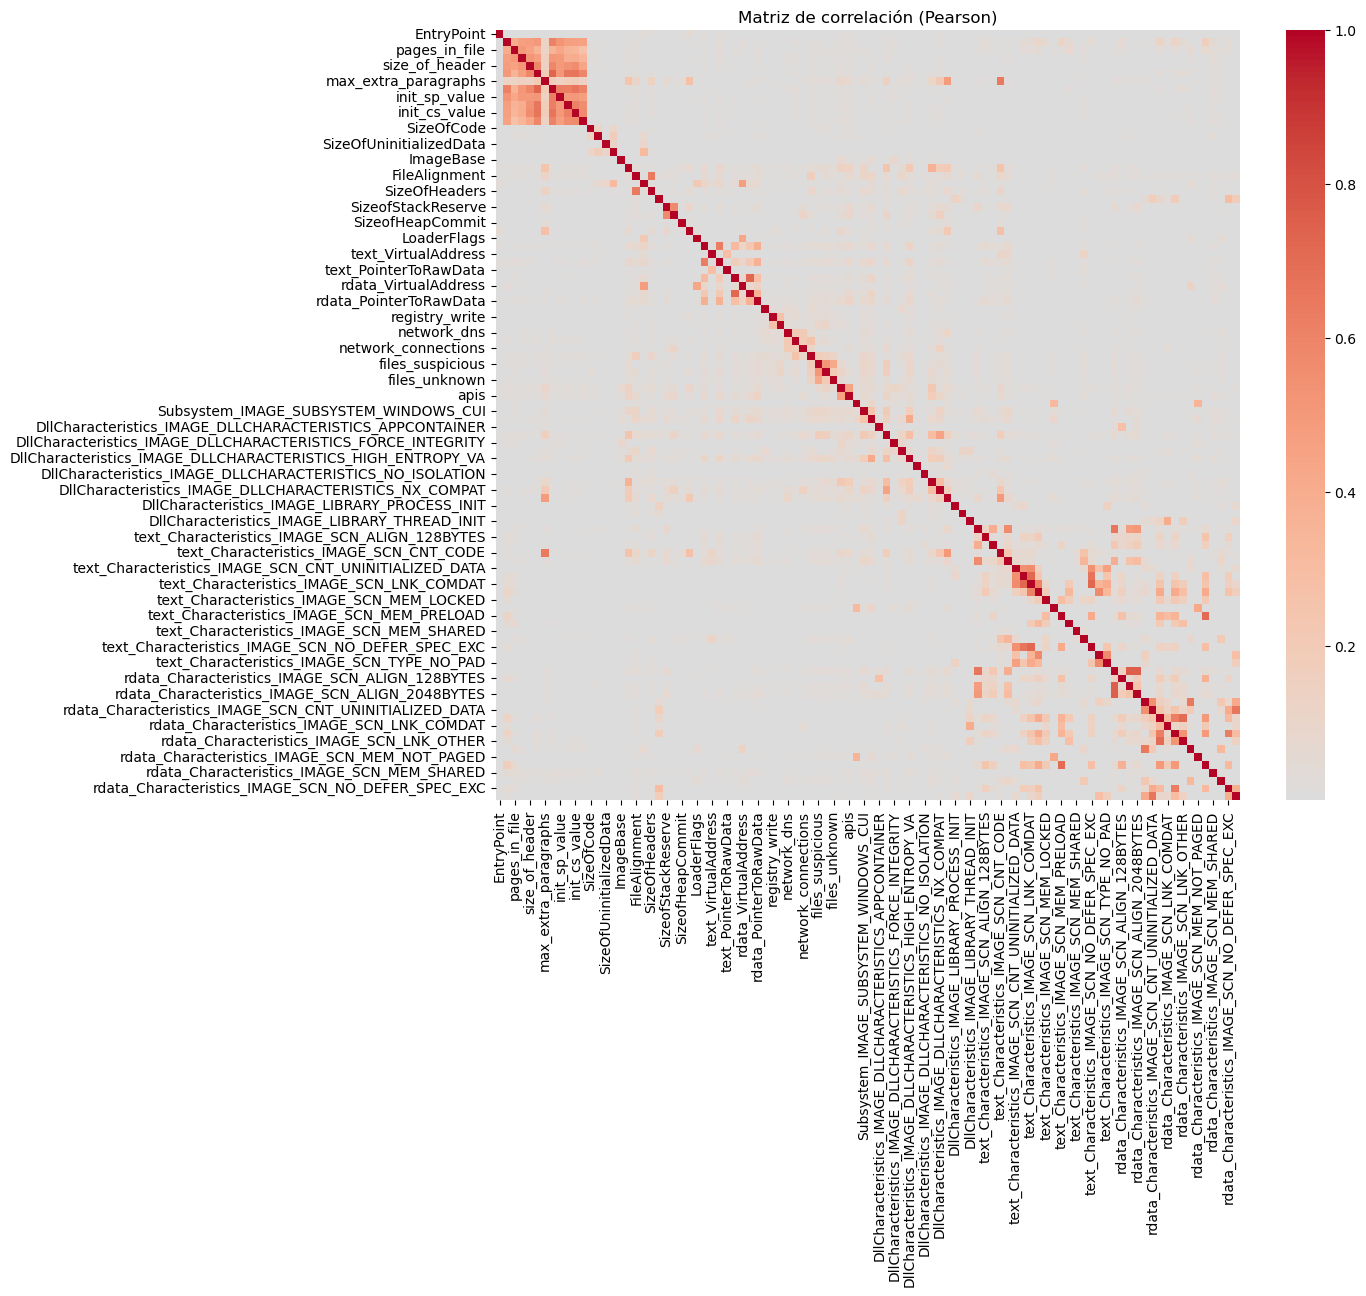

In [964]:

# === 1. Calcular matriz de correlación (Pearson) ===
corr_matrix = X.corr(method="pearson").abs()

# === 2. Visualización opcional ===
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matriz de correlación (Pearson)")
plt.show()




In [965]:

# === 3. Mantener solo parte superior de la matriz (para evitar duplicados)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# === 4. Definir umbral (ejemplo: 0.95)
umbral = 0.95

# === 5. Detectar pares de columnas altamente correlacionadas
correlated_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if upper.loc[row, col] > umbral
]

# === 6. Mostrar resultados
print(f"Número de pares de columnas con correlación > {umbral}: {len(correlated_pairs)}")
print("Ejemplos de pares correlacionados:")
for pair in correlated_pairs:
    print(pair)




Número de pares de columnas con correlación > 0.95: 0
Ejemplos de pares correlacionados:


In [966]:
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [column for column in upper.columns if any(upper[column] > 0.95)]
print("Columnas a eliminar por alta correlación:", len(high_corr))
X = X.drop(columns=high_corr)


Columnas a eliminar por alta correlación: 0


### F-TEST

In [967]:
from sklearn.feature_selection import f_classif
import numpy as np

def calcular_f_test_y_pvalues(X, y, alpha=0.05):
    # Asegurarse de tomar solo variables numéricas
    X_num = X.select_dtypes(include=[np.number])
    
    # Calcular F-test
    F, p = f_classif(X_num, y)
    
    resultados = []
    for feature, f_val, p_val in zip(X_num.columns, F, p):
        if p_val < alpha:
            resultados.append(f"La variable {feature} es linealmente DEPENDIENTE de la clase. p-value: {p_val:.2e}")
        else:
            resultados.append(f"La variable {feature} es linealmente INDEPENDIENTE de la clase. p-value: {p_val:.2e}")
    
    return resultados

# === Ejecución ===
resultados = calcular_f_test_y_pvalues(X, y)

for r in resultados:  
    print(r)


La variable EntryPoint es linealmente DEPENDIENTE de la clase. p-value: 3.94e-03
La variable bytes_on_last_page es linealmente DEPENDIENTE de la clase. p-value: 3.75e-04
La variable pages_in_file es linealmente DEPENDIENTE de la clase. p-value: 1.60e-07
La variable relocations es linealmente DEPENDIENTE de la clase. p-value: 9.45e-04
La variable size_of_header es linealmente DEPENDIENTE de la clase. p-value: 6.96e-03
La variable min_extra_paragraphs es linealmente DEPENDIENTE de la clase. p-value: 8.05e-06
La variable max_extra_paragraphs es linealmente DEPENDIENTE de la clase. p-value: 0.00e+00
La variable init_ss_value es linealmente DEPENDIENTE de la clase. p-value: 1.22e-06
La variable init_sp_value es linealmente DEPENDIENTE de la clase. p-value: 9.99e-04
La variable init_ip_value es linealmente DEPENDIENTE de la clase. p-value: 9.42e-04
La variable init_cs_value es linealmente DEPENDIENTE de la clase. p-value: 6.52e-04
La variable over_lay_number es linealmente DEPENDIENTE de la 

## Variables a eliminar

Ejemplos independientes (pueden descartarse si quieres reducir dimensionalidad):

SizeOfCode (p-value 0.15)

SizeOfInitializedData (p-value 0.42)

BaseOfCode, BaseOfData, ImageBase (~0.18)

text_Characteristics_IMAGE_SCN_ALIGN_128BYTES (0.21)

rdata_Characteristics_IMAGE_SCN_ALIGN_128BYTES (0.05 aprox)

rdata_Characteristics_IMAGE_SCN_MEM_LOCKED (0.75)

rdata_Characteristics_IMAGE_SCN_MEM_PRELOAD (0.75)

rdata_Characteristics_IMAGE_SCN_MEM_PURGEABLE (0.096)

rdata_Characteristics_IMAGE_SCN_TYPE_GROUP (0.083)
##333
92   text_Characteristics_IMAGE_SCN_CNT_UNINITIALIZ...  0.000000
149        rdata_Characteristics_IMAGE_SCN_TYPE_NO_PAD  0.000000
148        rdata_Characteristics_IMAGE_SCN_TYPE_NOLOAD  0.000000
147         rdata_Characteristics_IMAGE_SCN_TYPE_GROUP  0.000000
7                                        init_ss_value  0.000000
104          text_Characteristics_IMAGE_SCN_MEM_SHARED  0.000000
144  rdata_Characteristics_IMAGE_SCN_NO_DEFER_SPEC_EXC  0.000000
143          rdata_Characteristics_IMAGE_SCN_MEM_WRITE  0.000000
106   text_Characteristics_IMAGE_SCN_NO_DEFER_SPEC_EXC  0.000000
139        rdata_Characteristics_IMAGE_SCN_MEM_PRELOAD  0.000000
81         text_Characteristics_IMAGE_SCN_ALIGN_2BYTES  0.000000
110         text_Characteristics_IMAGE_SCN_TYPE_NO_PAD  0.000000
134          rdata_Characteristics_IMAGE_SCN_LNK_OTHER  0.000000
28                                         LoaderFlags  0.000000
99           text_Characteristics_IMAGE_SCN_MEM_LOCKED  0.000000
114     rdata_Characteristics_IMAGE_SCN_ALIGN_128BYTES  0.000000
130  rdata_Characteristics_IMAGE_SCN_CNT_UNINITIALI...  0.000000
63   DllCharacteristics_IMAGE_DLLCHARACTERISTICS_FO...  0.000000
95             text_Characteristics_IMAGE_SCN_LNK_INFO  0.000000
71       DllCharacteristics_IMAGE_LIBRARY_PROCESS_INIT  0.000000
101         text_Characteristics_IMAGE_SCN_MEM_PRELOAD  0.000000
73        DllCharacteristics_IMAGE_LIBRARY_THREAD_INIT  0.000000
94           text_Characteristics_IMAGE_SCN_LNK_COMDAT  0.000000
93                text_Characteristics_IMAGE_SCN_GPREL  0.000000
136        rdata_Characteristics_IMAGE_SCN_MEM_EXECUTE  0.000000

### Mutual Information
Mientras más alto el MI_score, más información aporta la variable para predecir la clase.

In [968]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd

# === 1. Calcular Mutual Information ===
mi_scores = mutual_info_classif(X, y, random_state=42)

# === 2. Crear DataFrame con resultados ===
df_mi = pd.DataFrame({
    "Feature": X.columns,
    "MI_score": mi_scores
}).sort_values(by="MI_score", ascending=False)

# === 3. Mostrar TODAS las filas en consola ===
pd.set_option("display.max_rows", None)
print(df_mi)




                                              Feature  MI_score
31                                  rdata_VirtualSize  0.627144
27                                   text_VirtualSize  0.609475
0                                          EntryPoint  0.555245
13                              SizeOfInitializedData  0.486992
34                             rdata_PointerToRawData  0.472226
42                                   files_suspicious  0.432729
29                                 text_SizeOfRawData  0.424127
12                                         SizeOfCode  0.423442
19                                        SizeOfImage  0.417098
44                                      files_unknown  0.373950
35                                      registry_read  0.362272
43                                         files_text  0.340394
32                               rdata_VirtualAddress  0.318992
46                                               apis  0.314547
33                                rdata_

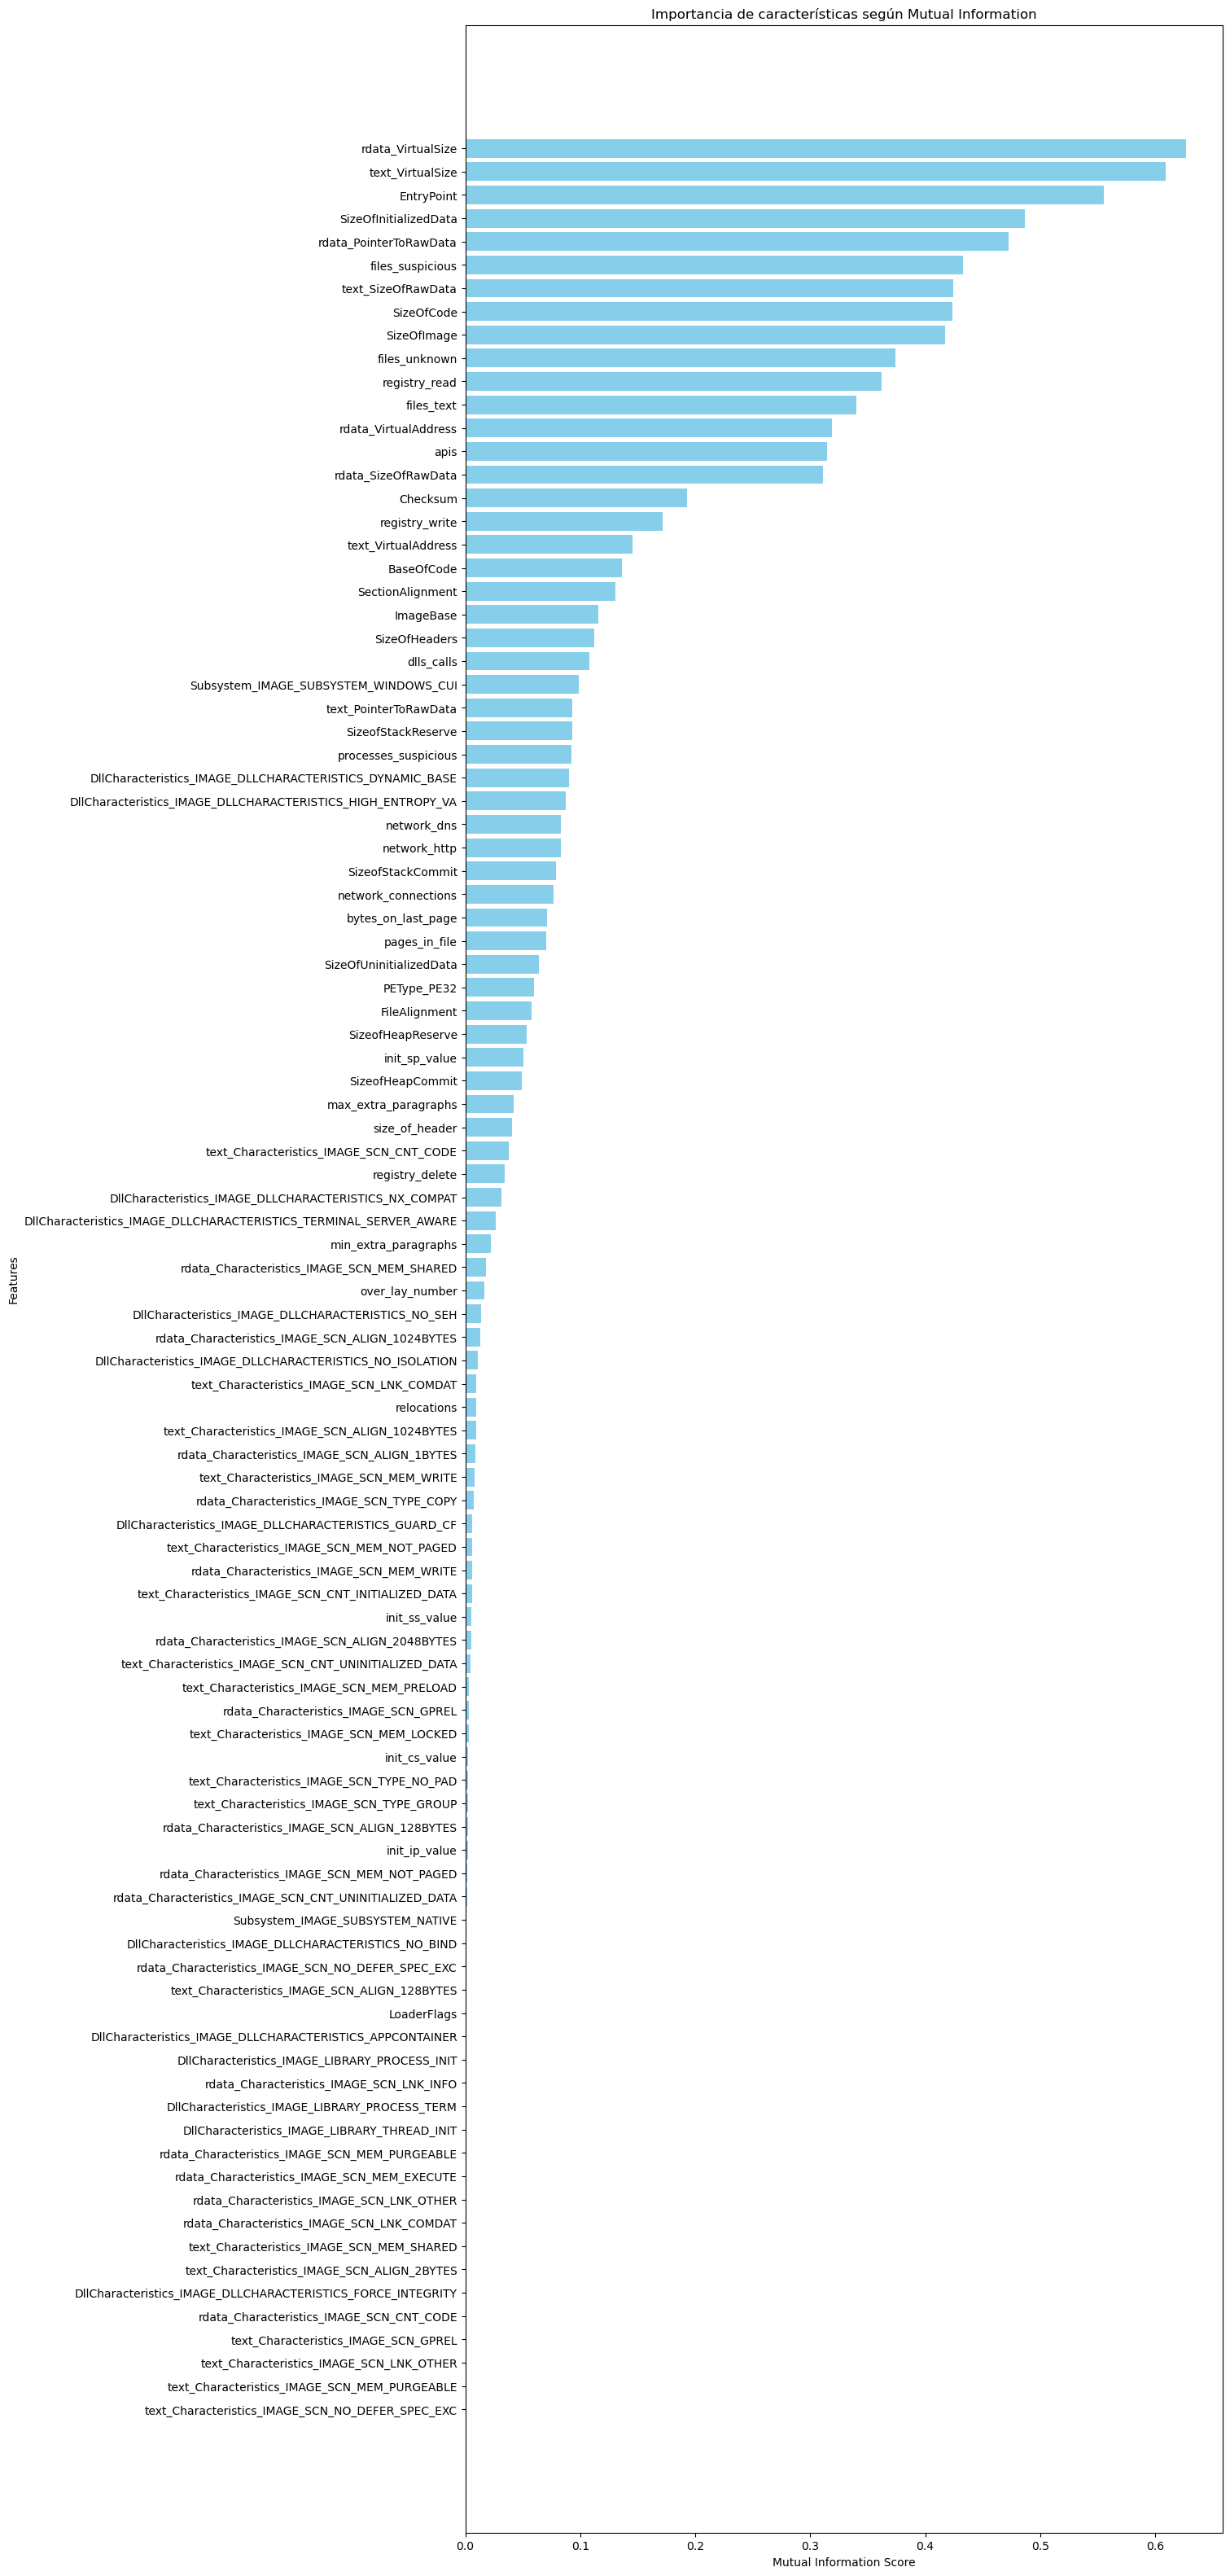

In [969]:
import matplotlib.pyplot as plt

# === Gráfico de barras con todas las características ===
plt.figure(figsize=(12, 40))  # alto grande para que entren todas
plt.barh(df_mi["Feature"], df_mi["MI_score"], color="skyblue")
plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Importancia de características según Mutual Information")
plt.gca().invert_yaxis()  # para que las más altas queden arriba
plt.show()


### Chi-Cuadradotest 
Chi-cuadrado (χ²) se usa principalmente cuando las variables son categóricas o discretas (incluyendo binarias como 0/1)

In [970]:
import pandas as pd
import numpy as np
from sklearn.feature_selection import chi2

# === 1. Detectar variables binarias (solo 0 y 1) ===
binarias = [col for col in X.columns if set(X[col].dropna().unique()).issubset({0, 1})]

# Crear nuevo DataFrame solo con variables categóricas/binarias
X_bin = X[binarias].copy().astype(int)

print(f"Variables seleccionadas para Chi²: {binarias}")

# === 2. Calcular Chi² ===
chi_scores, p_values = chi2(X_bin, y)

# === 3. DataFrame con resultados + interpretación ===
chi2_results = pd.DataFrame({
    "Feature": X_bin.columns,
    "Chi2_score": chi_scores,
    "p_value": p_values,
    "Relacion_con_clase": [
        "DEPENDIENTE (p < 0.05)" if p < 0.05 else "INDEPENDIENTE (p >= 0.05)"
        for p in p_values
    ]
}).sort_values(by="Chi2_score", ascending=False)

# === 4. Mostrar tabla ===
print("\n=== Resultados Chi² (solo variables categóricas/binarias) ===")
print(chi2_results)

# === 5. Mostrar mensajes detallados por variable ===
print("\n=== Interpretación variable por variable ===")
for feature, chi, p in zip(X_bin.columns, chi_scores, p_values):
    if p < 0.05:
        print(f"La variable '{feature}' es DEPENDIENTE de la clase (p={p:.4e}, Chi²={chi:.2f})")
    else:
        print(f"La variable '{feature}' es INDEPENDIENTE de la clase (p={p:.4e}, Chi²={chi:.2f})")


Variables seleccionadas para Chi²: ['Subsystem_IMAGE_SUBSYSTEM_NATIVE', 'Subsystem_IMAGE_SUBSYSTEM_WINDOWS_CUI', 'PEType_PE32', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_APPCONTAINER', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_DYNAMIC_BASE', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_FORCE_INTEGRITY', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_GUARD_CF', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_HIGH_ENTROPY_VA', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_BIND', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_ISOLATION', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NO_SEH', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_NX_COMPAT', 'DllCharacteristics_IMAGE_DLLCHARACTERISTICS_TERMINAL_SERVER_AWARE', 'DllCharacteristics_IMAGE_LIBRARY_PROCESS_INIT', 'DllCharacteristics_IMAGE_LIBRARY_PROCESS_TERM', 'DllCharacteristics_IMAGE_LIBRARY_THREAD_INIT', 'text_Characteristics_IMAGE_SCN_ALIGN_1024BYTES', 'text_Characteristics_IMAGE_SCN_ALIGN_128BYTES', 'text_Characteristics_IMAGE_SC

### Eliminacion de variables parte 2 

LoaderFlags

BaseOfCode

BaseOfData

ImageBase

text_Characteristics_IMAGE_SCN_ALIGN_128BYTES

rdata_Characteristics_IMAGE_SCN_ALIGN_128BYTES

rdata_Characteristics_IMAGE_SCN_MEM_LOCKED

rdata_Characteristics_IMAGE_SCN_MEM_PRELOAD

rdata_Characteristics_IMAGE_SCN_MEM_PURGEABLE

rdata_Characteristics_IMAGE_SCN_TYPE_GROUP

text_Characteristics_IMAGE_SCN_ALIGN_128BYTES (p=0.212, Chi²=3.10)

text_Characteristics_IMAGE_SCN_MEM_PRELOAD (p=0.751, Chi²=0.57)

text_Characteristics_IMAGE_SCN_MEM_PURGEABLE (p=0.424, Chi²=1.71)

text_Characteristics_IMAGE_SCN_MEM_SHARED (p=0.751, Chi²=0.57)

rdata_Characteristics_IMAGE_SCN_ALIGN_128BYTES (p=0.054, Chi²=5.81)

rdata_Characteristics_IMAGE_SCN_LNK_OTHER (p=0.289, Chi²=2.48)

rdata_Characteristics_IMAGE_SCN_MEM_LOCKED (p=0.751, Chi²=0.57)

rdata_Characteristics_IMAGE_SCN_MEM_PRELOAD (p=0.751, Chi²=0.57)

rdata_Characteristics_IMAGE_SCN_MEM_PURGEABLE (p=0.096, Chi²=4.68)

rdata_Characteristics_IMAGE_SCN_TYPE_GROUP (p=0.083, Chi²=4.97)

In [971]:
# Lista de variables a eliminar según Pearson, F-test, Chi²
vars_a_eliminar = [
    "LoaderFlags",
    "BaseOfCode",
    "BaseOfData",
    "ImageBase",
    "AddressOfEntryPoint",
   "text_Characteristics_IMAGE_SCN_ALIGN_128BYTES",
    "rdata_Characteristics_IMAGE_SCN_ALIGN_128BYTES",
    "rdata_Characteristics_IMAGE_SCN_MEM_LOCKED",
    "rdata_Characteristics_IMAGE_SCN_MEM_PRELOAD",
    "rdata_Characteristics_IMAGE_SCN_MEM_PURGEABLE",
    "rdata_Characteristics_IMAGE_SCN_TYPE_GROUP",
    "text_Characteristics_IMAGE_SCN_MEM_PRELOAD",
    "text_Characteristics_IMAGE_SCN_MEM_PURGEABLE",
    "text_Characteristics_IMAGE_SCN_MEM_SHARED",
    "rdata_Characteristics_IMAGE_SCN_LNK_OTHER"
]

# Crear nuevo dataset filtrado
X_limpio = X.drop(columns=vars_a_eliminar, errors="ignore")

print(f"Dataset original: {X.shape[1]} variables")
print(f"Variables eliminadas: {len(vars_a_eliminar)}")
print(f"Dataset final: {X_limpio.shape[1]} variables")


Dataset original: 98 variables
Variables eliminadas: 15
Dataset final: 88 variables


### Balanceo de clases

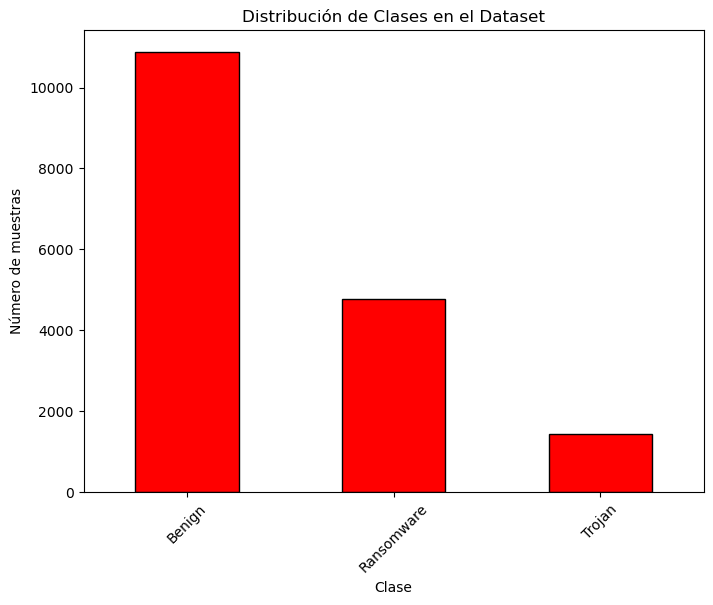

In [972]:

# Contar las clases
class_counts = y.value_counts()

# Gráfico de barras
plt.figure(figsize=(8,6))
class_counts.plot(kind='bar', color='red', edgecolor='black')

plt.title("Distribución de Clases en el Dataset")
plt.xlabel("Clase")
plt.ylabel("Número de muestras")
plt.xticks(rotation=45)
plt.show()


### Conversion a label encoder de la variable objetivo

In [973]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y)

print(le.classes_)  
# ['Benign' 'Ransomware' 'Trojan']


['Benign' 'Ransomware' 'Trojan']


In [974]:
print(y.head(10))     # originales
print(y_enc[:10])     # convertidos


0    Benign
1    Benign
2    Benign
3    Benign
4    Benign
5    Benign
6    Benign
7    Benign
8    Benign
9    Benign
Name: Category, dtype: object
[0 0 0 0 0 0 0 0 0 0]


### Dividir el conjunto de train/test

In [975]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_enc, test_size = 0.20, random_state=42, stratify=y_enc)


In [976]:
# Si quieres solo tamaños:
print("\nTamaños de los conjuntos:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)


Tamaños de los conjuntos:
X_train: (13668, 98)
y_train: (13668,)
X_test: (3417, 98)
y_test: (3417,)


In [977]:
from collections import Counter

print("Clases en y_train:", set(y_train))
print("Distribución:", Counter(y_train))

Clases en y_train: {0, 1, 2}
Distribución: Counter({0: 8699, 1: 3810, 2: 1159})


### Aplicar Ubdersampling

In [978]:
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

# Conteo original
conteo = Counter(y_train)
print("Distribución original:", conteo)

# Queremos llevar todas las clases al nivel de Trojan (clase 2)
min_count = conteo[2]

rus = RandomUnderSampler(
    sampling_strategy={0: min_count, 1: min_count, 2: min_count},
    random_state=42
)

X_train_bal, y_train_bal = rus.fit_resample(X_train, y_train)
print("Después del undersampling uniforme:", Counter(y_train_bal))


Distribución original: Counter({0: 8699, 1: 3810, 2: 1159})
Después del undersampling uniforme: Counter({0: 1159, 1: 1159, 2: 1159})


### Grafico despues de aplicar la tecnica de undersampling

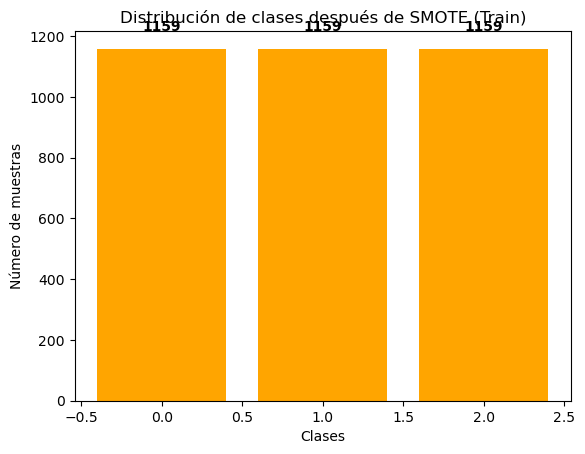

In [979]:
from collections import Counter
import matplotlib.pyplot as plt

# Contar clases después de SMOTE
class_counts = Counter(y_train_bal)

# Gráfico
plt.bar(class_counts.keys(), class_counts.values(), color="orange")
plt.title("Distribución de clases después de SMOTE (Train)")
plt.xlabel("Clases")
plt.ylabel("Número de muestras")

# Mostrar valores encima de cada barra
for clase, count in class_counts.items():
    plt.text(clase, count + 50, str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


### Entrenamiento del modelo con Random Forest

In [988]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Definir modelo
model = GradientBoostingClassifier(
    n_estimators=50,      # número de árboles
    learning_rate=0.1,    # qué tanto aprende cada árbol
    max_depth=3,          # profundidad máxima de cada árbol
    random_state=42
)

# Calcular pesos balanceados para las clases
weights = compute_sample_weight(class_weight="balanced", y=y_train_bal)

# Entrenar modelo con sample_weight
model.fit(X_train_bal, y_train_bal, sample_weight=weights)


,loss,'log_loss'
,learning_rate,0.1
,n_estimators,50
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


### Evaluar el modelo


In [981]:
y_pred = model.predict(X_test)


In [982]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nEvaluacion del modelo:\n", classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.9528826455955517

Evaluacion del modelo:
               precision    recall  f1-score   support

      Benign       0.99      0.95      0.97      2175
  Ransomware       0.97      0.96      0.96       952
      Trojan       0.72      0.98      0.83       290

    accuracy                           0.95      3417
   macro avg       0.89      0.96      0.92      3417
weighted avg       0.96      0.95      0.95      3417



In [983]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y_enc, cv=5, scoring="accuracy")
print("Accuracy promedio CV:", scores.mean())


Accuracy promedio CV: 0.9294117647058824


### Metricas de evaluacion

### Matriz de confusion

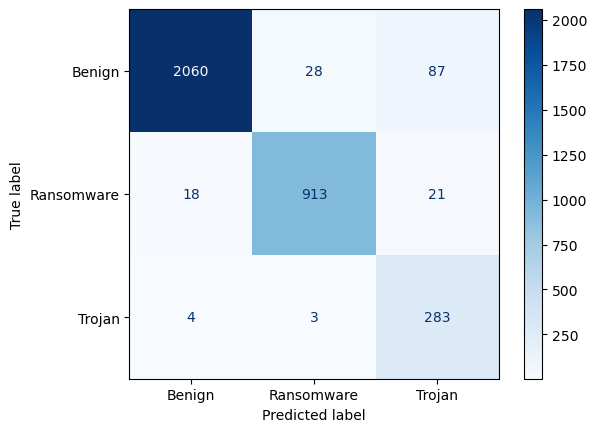

In [984]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap="Blues")


### Curva Roc

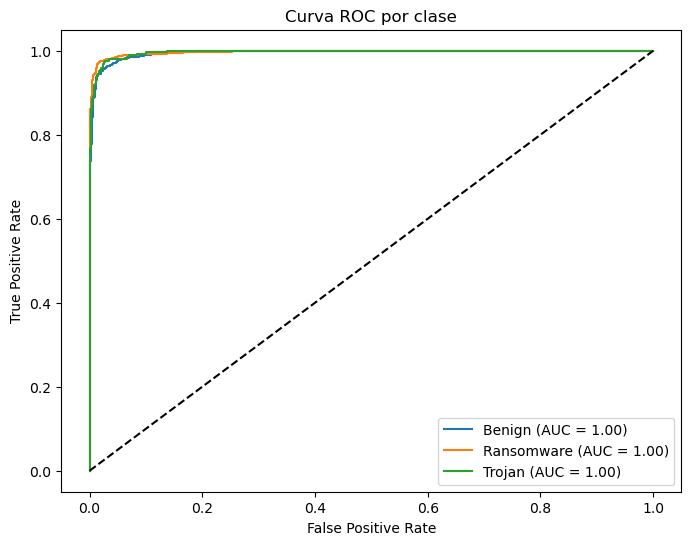

In [985]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Binarizamos las etiquetas reales (One-vs-Rest)
y_test_bin = label_binarize(y_test, classes=[0,1,2])  # 3 clases
y_pred_prob = model.predict_proba(X_test)  # probabilidades en lugar de clases

# Calcular ROC y AUC para cada clase
fpr = {}
tpr = {}
roc_auc = {}
for i in range(3):  # para cada clase
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Graficar curvas ROC
plt.figure(figsize=(8,6))
for i, clase in enumerate(le.classes_):
    plt.plot(fpr[i], tpr[i], label=f"{clase} (AUC = {roc_auc[i]:.2f})")

# Línea diagonal (modelo aleatorio)
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC por clase")
plt.legend(loc="lower right")
plt.show()


### Valor AUC

In [986]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score

# Binarizar y calcular probabilidades
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_pred_prob = model.predict_proba(X_test)

# Calcular AUC promedio
auc_macro = roc_auc_score(y_test_bin, y_pred_prob, average="macro")
auc_weighted = roc_auc_score(y_test_bin, y_pred_prob, average="weighted")

print("AUC Macro promedio:", auc_macro)
print("AUC Ponderado:", auc_weighted)


AUC Macro promedio: 0.9960015770532259
AUC Ponderado: 0.9955885868993036


In [987]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y_enc, cv=5, scoring="accuracy")
print("Accuracies CV:", scores)
print("Promedio:", scores.mean())


Accuracies CV: [0.96283289 0.91922739 0.97336845 0.93590869 0.85572139]
Promedio: 0.9294117647058824
